In [11]:
import pandas as pd
import numpy as np
import calendar
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_absolute_error
from catboost import CatBoostRegressor
import lightgbm as lgb
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('/kaggle/input/datasets/viacheslavkrutoyatov/x5-hse-2/train_2.csv')

In [12]:
df.head()

,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,...,"Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,74209339.11


EDA

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485082 entries, 0 to 485081
Data columns (total 24 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   new_id                                     485082 non-null  int64  
 1   Год                                        485082 non-null  int64  
 2   Месяц                                      485082 non-null  int64  
 3   Среднее количество промо товаров в чеке    485082 non-null  float64
 4   Среднее количество товаров в чеке          485082 non-null  float64
 5   Среднее количество отмен                   485082 non-null  float64
 6   Рабочие часы в день                        485082 non-null  float64
 7   Дата открытия, категориальный              485082 non-null  object 
 8   Торговая площадь, категориальный           485082 non-null  object 
 9   Населенный пункт                           485082 non-null  object 
 10  Регион  

In [14]:
print(df['РТО'].describe())
print(df['РТО'].skew())

count    4.850820e+05
mean     8.853480e+07
std      4.824900e+07
min      1.179116e+06
25%      5.627279e+07
50%      7.521094e+07
75%      1.057677e+08
max      6.557204e+08
Name: РТО, dtype: float64
1.9860235779446298


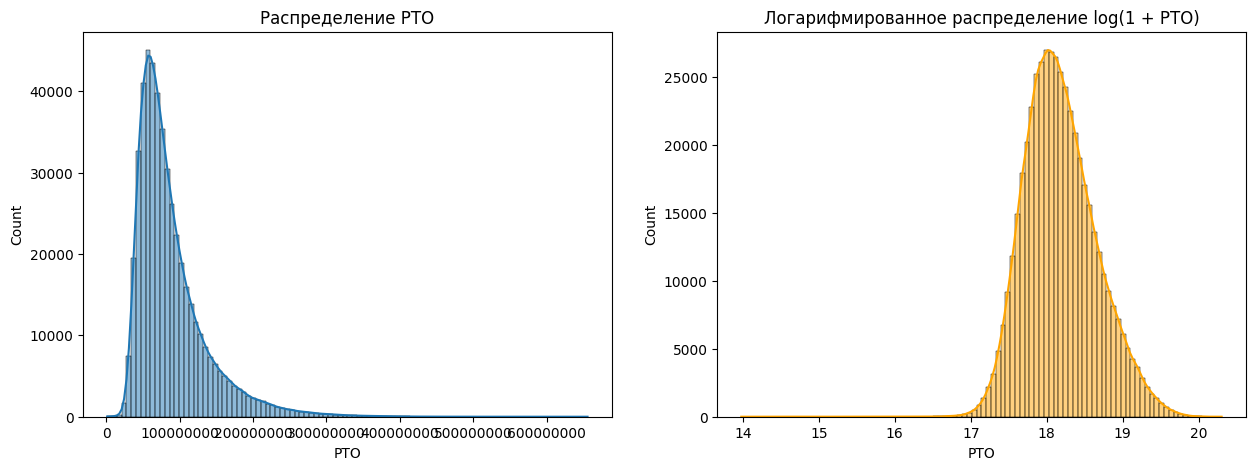

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['РТО'], bins=100, kde=True, ax=axes[0])
axes[0].set_title('Распределение РТО')
axes[0].ticklabel_format(style='plain')

sns.histplot(np.log1p(df['РТО']), bins=100, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Логарифмированное распределение log(1 + РТО)')

plt.show()

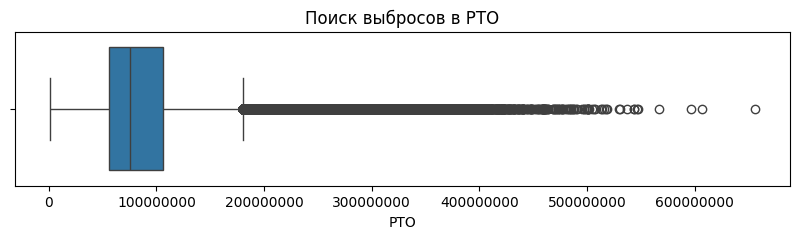

,new_id,Год,Месяц,РТО
216809,9754,2023,10,6.557204e+08
142236,6389,2024,8,6.069936e+08
142235,6389,2024,7,5.965186e+08
285182,12812,2024,7,5.667146e+08
285180,12812,2024,6,5.474707e+08
130779,5884,2024,12,5.466047e+08
469340,21032,2024,7,5.436554e+08
322061,14419,2024,12,5.432477e+08
71931,3241,2024,7,5.368106e+08
148433,6673,2024,12,5.308997e+08


In [16]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['РТО'])
plt.ticklabel_format(style='plain', axis='x')
plt.title('Поиск выбросов в РТО')
plt.show()

display(df.nlargest(10, 'РТО')[['new_id', 'Год', 'Месяц', 'РТО']])

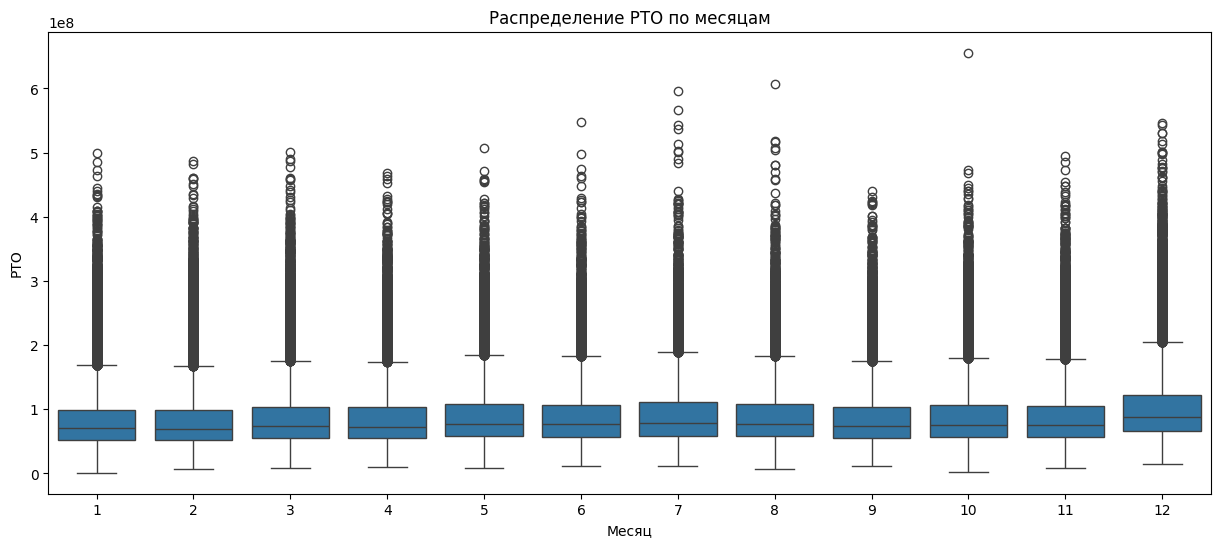

In [17]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df, x='Месяц', y='РТО')
plt.title('Распределение РТО по месяцам')
plt.show()

In [18]:
import pandas as pd
import numpy as np

print(f"new_id: {df['new_id'].nunique()}")
print(f"Year range: {df['Год'].min()} - {df['Год'].max()}")
print(f"Months in dataset: {sorted(df['Месяц'].unique())}")

history_len = df.groupby('new_id').size()
print(f"\nHistory per store:")
print(f"  min months: {history_len.min()}")
print(f"  mean months: {history_len.mean():.1f}")
print(f"  max months: {history_len.max()}")

print(f"\nRTO stats:")
print(f"  min RTO: {df['РТО'].min():.2f}")
print(f"  RTO <= 0: {(df['РТО'] <= 0).sum()}")
print(f"  RTO NaN: {df['РТО'].isna().sum()}")

cols_to_check = ['Среднее количество товаров в чеке', 
                 'Среднее количество промо товаров в чеке', 
                 'Среднее количество отмен', 
                 'Рабочие часы в день']
print(f"\nFeature stats:")
print(df[cols_to_check].describe().round(2))

new_id: 18657
Year range: 2023 - 2025
Months in dataset: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

History per store:
  min months: 26
  mean months: 26.0
  max months: 26

RTO stats:
  min RTO: 1179116.01
  RTO <= 0: 0
  RTO NaN: 0

Feature stats:
       Среднее количество товаров в чеке  \
count                          485082.00   
mean                                5.28   
std                                 1.05   
min                                 1.65   
25%                                 4.55   
50%                                 5.13   
75%                                 5.85   
max                                23.49   

       Среднее количество промо товаров в чеке  Среднее количество отмен  \
count                                485082.00                 485082.00   
mean                                      0.96                    273.60   
std    

In [19]:
print("Stores with working hours > 24:")
print(df[df['Рабочие часы в день'] > 24][['new_id', 'Год', 'Месяц', 'Рабочие часы в день', 'Количество касс', 'РТО']].head())

print("\nTop-5 cancellations:")
print(df.nlargest(5, 'Среднее количество отмен')[['new_id', 'Год', 'Месяц', 'Среднее количество отмен', 'РТО']])


Stores with working hours > 24:
      new_id   Год  Месяц  Рабочие часы в день  Количество касс          РТО
3198     136  2024      1                 26.0                6  40783684.51
3199     136  2025      1                 26.0                6  80076029.91
3200     136  2023      1                 26.0                6  57781095.48
3201     136  2023      2                 26.0                6  56534402.67
3202     136  2025      2                 26.0                6  79995856.27

Top-5 cancellations:
        new_id   Год  Месяц  Среднее количество отмен           РТО
303474   13611  2023      1                   22507.0  8.478739e+07
142235    6389  2024      7                    9789.0  5.965186e+08
142236    6389  2024      8                    8478.0  6.069936e+08
142233    6389  2024      6                    7684.0  4.603767e+08
103599    4667  2024      7                    7089.0  3.771696e+08


In [20]:
import pandas as pd
import numpy as np

df.loc[df['Рабочие часы в день'] > 24, 'Рабочие часы в день'] = 24.0

pivot_rto = df.pivot_table(index='Месяц', columns='Год', values='РТО', aggfunc='mean')
print(pivot_rto)

print("\nMarch coefficient (Feb -> Mar):")
if 2023 in pivot_rto.columns and 2024 in pivot_rto.columns:
    print(f"  2023: {pivot_rto.loc[3, 2023] / pivot_rto.loc[2, 2023]:.3f}")
    print(f"  2024: {pivot_rto.loc[3, 2024] / pivot_rto.loc[2, 2024]:.3f}")

feb_2025 = df[(df['Год'] == 2025) & (df['Месяц'] == 2)]
jan_2023 = df[(df['Год'] == 2023) & (df['Месяц'] == 1)]

store_growth = feb_2025.set_index('new_id')['РТО'] / jan_2023.set_index('new_id')['РТО']
print("\nStore growth quantiles (2-year):")
print(store_growth.quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

df['promo_share'] = df['Среднее количество промо товаров в чеке'] / (df['Среднее количество товаров в чеке'] + 1e-5)
print("\nAvg promo share by month:")
print(df.groupby('Месяц')['promo_share'].mean())


Год            2023          2024          2025
Месяц                                          
1      7.294137e+07  8.250019e+07  9.414061e+07
2      7.110712e+07  8.450857e+07  9.171339e+07
3      8.023747e+07  9.379216e+07           NaN
4      8.040807e+07  9.216413e+07           NaN
5      8.441712e+07  9.714561e+07           NaN
6      8.284801e+07  9.588640e+07           NaN
7      8.538163e+07  9.879009e+07           NaN
8      8.449562e+07  9.545146e+07           NaN
9      8.123091e+07  9.119891e+07           NaN
10     8.406210e+07  9.432789e+07           NaN
11     8.289331e+07  9.406005e+07           NaN
12     9.706895e+07  1.091336e+08           NaN

March coefficient (Feb -> Mar):
  2023: 1.128
  2024: 1.110

Store growth quantiles (2-year):
0.05    0.922257
0.25    1.118111
0.50    1.251276
0.75    1.405245
0.95    1.764770
Name: РТО, dtype: float64

Avg promo share by month:
Месяц
1     0.164645
2     0.184616
3     0.211957
4     0.217012
5     0.204208
6     0.182932

In [12]:
def generate_advanced_features(df):
    df = df.copy()
    df.loc[df['Рабочие часы в день'] > 24, 'Рабочие часы в день'] = 24.0
    
    df = df.sort_values(by=['new_id', 'Год', 'Месяц']).reset_index(drop=True)
    
    df['promo_share'] = df['Среднее количество промо товаров в чеке'] / (df['Среднее количество товаров в чеке'] + 1e-5)
    df['cancellations_per_hour'] = df['Среднее количество отмен'] / (df['Рабочие часы в день'] + 1e-5)
    
    df['lag_1'] = df.groupby('new_id')['РТО'].shift(1)
    df['lag_2'] = df.groupby('new_id')['РТО'].shift(2)
    df['lag_3'] = df.groupby('new_id')['РТО'].shift(3)
    
    df['lag_12'] = df.groupby('new_id')['РТО'].shift(12)
    df['lag_13'] = df.groupby('new_id')['РТО'].shift(13)
    df['lag_24'] = df.groupby('new_id')['РТО'].shift(24)
    
    df['historical_march_bump'] = df['lag_12'] / (df['lag_13'] + 1e-5)
    
    df['feb_yoy_momentum'] = df['lag_1'] / (df['lag_13'] + 1e-5)
    
    df['trend_1m'] = df['lag_1'] / (df['lag_2'] + 1e-5)
    
    df['promo_share_lag_1'] = df.groupby('new_id')['promo_share'].shift(1)
    df['promo_share_lag_12'] = df.groupby('new_id')['promo_share'].shift(12)
    
    df['cancellations_lag_1'] = df.groupby('new_id')['cancellations_per_hour'].shift(1)
    
    df['mean_3m'] = df.groupby('new_id')['lag_1'].rolling(window=3).mean().reset_index(level=0, drop=True)
    
    return df

df_features = generate_advanced_features(df)


In [13]:
import pandas as pd
import numpy as np

print("Checking geo features for static nature:")

geo_cols = ['Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 'Пятерочки (500 м)']
geo_stats = df_features.groupby('new_id')[geo_cols].nunique().mean()
print(geo_stats)

print("\nCorrelation with March 2024 bump:")
march_24 = df_features[(df_features['Год'] == 2024) & (df_features['Месяц'] == 3)].copy()

march_24['real_march_bump'] = march_24['РТО'] / (march_24['lag_1'] + 1e-5)

cols_to_corr = ['Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 
                'Трафик авто, в час', 'Пятерочки (500 м)', 'Продуктовые магазины (500 м)']
print(march_24[cols_to_corr].corrwith(march_24['real_march_bump']).round(4))

print("\nTop-10 regions by March bump:")
print(march_24.groupby('Регион')['real_march_bump'].mean().sort_values(ascending=False).head(10))


Checking geo features for static nature:
Численность населения      1.0
Количество домохозяйств    1.0
Трафик пеший, в час        1.0
Пятерочки (500 м)          1.0
dtype: float64

Correlation with March 2024 bump:
Численность населения           0.0198
Количество домохозяйств        -0.0652
Трафик пеший, в час            -0.0497
Трафик авто, в час              0.0171
Пятерочки (500 м)              -0.0631
Продуктовые магазины (500 м)   -0.0747
dtype: float64

Top-10 regions by March bump:
Регион
Мордовия Респ        1.187181
Алтай Респ           1.143270
Ленинградская обл    1.139950
Московская обл       1.136522
Хакасия Респ         1.134744
Оренбургская обл     1.131947
Москва г             1.130805
Марий Эл Респ        1.129355
Смоленская обл       1.127316
Костромская обл      1.126616
Name: real_march_bump, dtype: float64


In [21]:
import numpy as np
import pandas as pd
import calendar
import re
import warnings
from catboost import CatBoostRegressor
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def preprocess_and_generate_features_v3(df):
    data = df.copy()
    
    # 1. Базовая очистка операционных признаков
    data['Рабочие часы в день'] = data['Рабочие часы в день'].clip(upper=24)
    cancel_q99 = data['Среднее количество отмен'].quantile(0.99)
    data['Среднее количество отмен'] = data['Среднее количество отмен'].clip(upper=cancel_q99)

    # 2. Сводная таблица РТО по (store, year, month)
    rto_pivot = data.pivot(index='new_id', columns=['Год', 'Месяц'], values='РТО')

    # 3. Выделение статичных социально-географических характеристик
    static_cols = [
        'new_id', 'Регион', 'Населенный пункт', 'Дата открытия, категориальный',
        'Торговая площадь, категориальный', 'Численность населения', 'Количество домохозяйств',
        'Трафик пеший, в час', 'Трафик авто, в час', 'Маркетплейсы, доставки, постаматы (100 м)',
        'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)',
        'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии'
    ]
    store_info = data[static_cols].drop_duplicates(subset=['new_id']).set_index('new_id')

    # Вспомогательные календарные функции
    def count_weekends(yr, mo):
        cal = calendar.Calendar()
        return sum(1 for d in cal.itermonthdays2(yr, mo) if d[0] != 0 and d[1] in (5, 6))

    # Внутренняя функция сборки датасета под конкретный Март
    def build_dataset_for_march(target_year):
        base_year = target_year
        prev_year = target_year - 1
        df_feat = store_info.copy()
        
        # --- Новые календарные фичи (влияние структуры дней недели) ---
        df_feat['mar_weekends'] = count_weekends(base_year, 3)
        df_feat['feb_weekends'] = count_weekends(base_year, 2)
        
        # --- Базовые лаги РТО ---
        has_dec = (base_year - 1, 12) in rto_pivot.columns
        has_prev_mar = (prev_year, 3) in rto_pivot.columns
        has_prev_feb = (prev_year, 2) in rto_pivot.columns
        has_prev_jan = (prev_year, 1) in rto_pivot.columns
        
        df_feat['RTO_base_Feb'] = rto_pivot[(base_year, 2)]
        df_feat['RTO_base_Jan'] = rto_pivot[(base_year, 1)]
        df_feat['RTO_base_Dec'] = rto_pivot[(base_year - 1, 12)] if has_dec else np.nan
        df_feat['RTO_prev_Mar'] = rto_pivot[(prev_year, 3)] if has_prev_mar else np.nan
        df_feat['RTO_prev_Feb'] = rto_pivot[(prev_year, 2)] if has_prev_feb else np.nan
        
        # --- Базовые отношения и тренды ---
        df_feat['jan_dec_drop'] = df_feat['RTO_base_Jan'] / df_feat['RTO_base_Dec'].replace(0, np.nan)
        df_feat['feb_dec_ratio'] = df_feat['RTO_base_Feb'] / df_feat['RTO_base_Dec'].replace(0, np.nan)
        df_feat['hist_march_bump'] = df_feat['RTO_prev_Mar'] / df_feat['RTO_prev_Feb'].replace(0, np.nan)
        df_feat['regional_march_bump'] = df_feat.groupby('Регион')['hist_march_bump'].transform('mean')
        df_feat['store_growth_1y'] = df_feat['RTO_base_Feb'] / df_feat['RTO_prev_Feb'].replace(0, np.nan)
        df_feat['recent_trend_1m'] = df_feat['RTO_base_Feb'] / df_feat['RTO_base_Jan'].replace(0, np.nan)
        
        regional_mean = df_feat.groupby('Регион')['RTO_base_Feb'].transform('mean')
        df_feat['rto_vs_region_mean'] = df_feat['RTO_base_Feb'] / regional_mean.replace(0, np.nan)
        
        # --- Февральские операционные метрики ---
        feb_stats = data[(data['Год'] == base_year) & (data['Месяц'] == 2)].set_index('new_id')
        df_feat['Feb_promo_share'] = feb_stats['Среднее количество промо товаров в чеке'] / feb_stats['Среднее количество товаров в чеке']
        df_feat['Feb_cancels'] = feb_stats['Среднее количество отмен']
        df_feat['Feb_work_hours'] = feb_stats['Рабочие часы в день']
        df_feat['organic_trend_index'] = df_feat['recent_trend_1m'] / (df_feat['Feb_promo_share'] + 0.01)
        
        total_traffic = df_feat['Трафик пеший, в час'] + df_feat['Трафик авто, в час'] + 1
        df_feat['tills_per_traffic'] = df_feat['Количество касс'] / total_traffic
        df_feat['scaled_march_bump'] = df_feat['hist_march_bump'] * df_feat['store_growth_1y']
        
        # --- Волатильность ---
        history_before_target = data[(data['Год'] * 12 + data['Месяц']) <= (base_year * 12 + 2)]
        recent_3m = history_before_target[(history_before_target['Год'] * 12 + history_before_target['Месяц']) > (base_year * 12 - 1)]
        df_feat['rto_roll_std_3m'] = recent_3m.groupby('new_id')['РТО'].std().fillna(0)
        
        # --- Гео-плотность и инфраструктура ---
        df_feat['rto_per_cashbox'] = df_feat['RTO_base_Feb'] / (df_feat['Количество касс'] + 1)
        df_feat['rto_to_traffic_ratio'] = df_feat['RTO_base_Feb'] / total_traffic
        df_feat['traffic_per_cashbox'] = total_traffic / (df_feat['Количество касс'] + 1)
        df_feat['infrastructure_density'] = (df_feat['Медицинские уч. и аптеки (300 м)'] +
                                             df_feat['Школы (300 м)'] + df_feat['Остановки (300 м)'])
        df_feat['pure_competitors_500m'] = df_feat['Продуктовые магазины (500 м)'] - df_feat['Пятерочки (500 м)']
        df_feat['region_alcohol'] = df_feat['Регион'].astype(str) + '_' + df_feat['Флаг алкогольной лицензии'].astype(str)
        
        days_in_feb = calendar.monthrange(base_year, 2)[1]
        df_feat['feb_rto_per_day'] = df_feat['RTO_base_Feb'] / days_in_feb
        df_feat['projected_mar_rto'] = df_feat['feb_rto_per_day'] * 31
        df_feat['log_rto_feb'] = np.log1p(df_feat['RTO_base_Feb'])
        df_feat['rto_per_household'] = df_feat['RTO_base_Feb'] / (df_feat['Количество домохозяйств'] + 1)
        
        # --- Конкурентная среда (Монополия) ---
        df_feat['monopoly_index'] = df_feat['Количество касс'] / (df_feat['Продуктовые магазины (500 м)'] + 1)
        df_feat['log_monopoly_index'] = np.log1p(df_feat['monopoly_index'])
        area_map = {'Mini': 1, 'Small': 2, 'Medium': 3, 'Large': 4, 'Extra Large': 5}
        df_feat['area_numeric'] = df_feat['Торговая площадь, категориальный'].map(area_map).fillna(2)
        df_feat['area_monopoly_index'] = df_feat['area_numeric'] / (df_feat['Продуктовые магазины (500 м)'] + 1)
        df_feat['household_per_competitor'] = df_feat['Количество домохозяйств'] / (df_feat['Продуктовые магазины (500 м)'] + 1)
        df_feat['pyaterochka_share_in_locale'] = df_feat['Пятерочки (500 м)'] / (df_feat['Продуктовые магазины (500 м)'] + 1)
        df_feat['infra_density_per_traffic'] = df_feat['infrastructure_density'] / (total_traffic + 1)
        
        # --- Внутрирегиональные ранги ---
        df_feat['rto_feb_regional_rank'] = df_feat.groupby('Регион')['RTO_base_Feb'].rank(pct=True)
        
        # --- Взаимодействия (Cross-features) ---
        df_feat['ratio_x_monopoly'] = df_feat['feb_dec_ratio'] * df_feat['monopoly_index']
        df_feat['trend_x_monopoly'] = df_feat['recent_trend_1m'] * df_feat['monopoly_index']
        df_feat['top1_x_top2'] = df_feat['feb_dec_ratio'] * df_feat['recent_trend_1m']
        df_feat['top1_div_top2'] = df_feat['feb_dec_ratio'] / (df_feat['recent_trend_1m'] + 0.001)
        
        df_feat['alc_binary'] = df_feat['Флаг алкогольной лицензии'].map({'Y': 1, 'N': 0, 1: 1, 0: 0}).fillna(0)
        df_feat['alc_x_pedestrian_traffic'] = df_feat['alc_binary'] * df_feat['Трафик пеший, в час']
        df_feat['alc_x_feb_rto'] = df_feat['alc_binary'] * df_feat['RTO_base_Feb']
        
        df_feat['trend_acceleration'] = df_feat['recent_trend_1m'] / (df_feat['jan_dec_drop'] + 0.001)
        df_feat['promo_pressure_per_household'] = df_feat['Feb_promo_share'] * df_feat['Количество домохозяйств']
        
        if has_prev_jan:
            df_feat['store_growth_jan_1y'] = rto_pivot[(base_year, 1)] / rto_pivot[(prev_year, 1)]
            df_feat['stable_yoy_growth'] = df_feat[['store_growth_1y', 'store_growth_jan_1y']].mean(axis=1)
        else:
            df_feat['store_growth_jan_1y'] = np.nan
            df_feat['stable_yoy_growth'] = df_feat['store_growth_1y']
        
        months_3 = []
        for pair in [(base_year, 2), (base_year, 1), (base_year-1, 12)]:
            if pair in rto_pivot.columns:
                months_3.append(rto_pivot[pair])
        if len(months_3) >= 2:
            df_feat['rto_median_last_3m'] = pd.concat(months_3, axis=1).median(axis=1)
            df_feat['rto_ma_3m'] = pd.concat(months_3, axis=1).mean(axis=1)
            df_feat['feb_vs_median_3m'] = df_feat['RTO_base_Feb'] / (df_feat['rto_median_last_3m'] + 1)
            df_feat['feb_vs_ma_3m'] = df_feat['RTO_base_Feb'] / (df_feat['rto_ma_3m'] + 1)
        else:
            df_feat['feb_vs_median_3m'] = 1.0
            df_feat['feb_vs_ma_3m'] = 1.0
        
        df_feat['jan_feb_compression'] = df_feat['RTO_base_Jan'] / (df_feat['RTO_base_Feb'] + 1)
        df_feat['rebound_potential'] = df_feat['jan_feb_compression'] * df_feat['hist_march_bump']
        df_feat['pedestrian_conversion_efficiency'] = df_feat['RTO_base_Feb'] / (df_feat['Трафик пеший, в час'] + 1)
        competitors_penalty = (df_feat['Продуктовые магазины (500 м)'] + 1) ** 1.5
        df_feat['pure_oasis_index'] = df_feat['Количество домохозяйств'] / competitors_penalty
        
        # Расчет коэффициента-таргета (отношение марта к февралю)
        if (target_year, 3) in rto_pivot.columns:
            target_rto = rto_pivot[(target_year, 3)]
            target = target_rto / df_feat['RTO_base_Feb'].replace(0, np.nan)
        else:
            target = None
            
        return df_feat, target

    # --- УМНАЯ АВТО-ГЕНЕРАЦИЯ ИСТОРИИ ---
    # Находим все уникальные годы, где в истории присутствует Март (месяц == 3)
    available_years = sorted(list(set([pair[0] for pair in rto_pivot.columns if pair[1] == 3])))
    # Исключаем 2025 год, так как это наш целевой тестовый период
    target_years = [yr for yr in available_years if yr != 2025]
    print(f"Обнаружены исторические периоды для обучения за годы: {target_years}")

    X_train_list, y_train_list = [], []
    for yr in target_years:
        try:
            X_tr_yr, y_tr_yr = build_dataset_for_march(target_year=yr)
            if y_tr_yr is not None:
                X_train_list.append(X_tr_yr)
                y_train_list.append(y_tr_yr)
        except Exception as e:
            print(f"Пропускаем исторический {yr} год из-за нехватки лагов: {e}")
            
    X_train = pd.concat(X_train_list, axis=0) if X_train_list else pd.DataFrame()
    y_train = pd.concat(y_train_list, axis=0) if y_train_list else pd.Series()
    
    # Сборка теста под Март 2025
    X_test, _ = build_dataset_for_march(target_year=2025)
    
    # Синхронизация признаков
    common_cols = X_train.columns.intersection(X_test.columns)
    X_train = X_train[common_cols]
    X_test = X_test[common_cols]
    
    return X_train, y_train, X_test

# 1. Запуск генерации признаков
print('Шаг 1: Сборка датасета и расчет признаков...')
X_train, y_train, X_test = preprocess_and_generate_features_v3(df)
print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')

Шаг 1: Сборка датасета и расчет признаков...
Обнаружены исторические периоды для обучения за годы: [2023, 2024]
X_train shape: (37314, 74), X_test shape: (18657, 74)


In [22]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

cat_features = ['Регион', 'Населенный пункт', 'Дата открытия, категориальный', 'Торговая площадь, категориальный', 'region_alcohol']
for col in cat_features:
    X_train[col] = X_train[col].fillna('Unknown').astype(str)
    X_test[col] = X_test[col].fillna('Unknown').astype(str)

# 3. Отделяем таргет-образующие лаги
cols_to_drop = ['RTO_base_Feb', 'RTO_base_Jan', 'RTO_base_Dec', 'RTO_prev_Mar', 'RTO_prev_Feb']
X_train_pure = X_train.drop(columns=cols_to_drop)
X_test_pure = X_test.drop(columns=cols_to_drop)

# 4. ЗАЩИТА: Синхронная очистка X и y от NaN и Inf в таргете
good_rows = np.isfinite(y_train) & (X_train['RTO_base_Feb'] > 0)
X_train_pure = X_train_pure[good_rows]
y_train = y_train[good_rows]

# 5. Валидационный сплит (теперь размеры совпадут на 100%)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pure, y_train, 
    test_size=0.15, 
    random_state=42 
)


model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    early_stopping_rounds=150,
    verbose=100
)

model.fit(
    X_tr, y_tr,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    plot=False 
)

print(f"Лучшая итерация: {model.best_iteration_}")
print(f"MAE на валидации: {model.best_score_['validation']['MAE']:.5f}")

0:	learn: 0.0436240	test: 0.0401342	best: 0.0401342 (0)	total: 35.8ms	remaining: 1m 11s
100:	learn: 0.0368728	test: 0.0349152	best: 0.0349152 (100)	total: 3.64s	remaining: 1m 8s
200:	learn: 0.0355850	test: 0.0343486	best: 0.0343486 (200)	total: 7.06s	remaining: 1m 3s
300:	learn: 0.0350339	test: 0.0341523	best: 0.0341515 (297)	total: 10.6s	remaining: 59.8s
400:	learn: 0.0345819	test: 0.0340747	best: 0.0340735 (396)	total: 14.1s	remaining: 56s
500:	learn: 0.0340683	test: 0.0339784	best: 0.0339784 (500)	total: 17.6s	remaining: 52.5s
600:	learn: 0.0336986	test: 0.0339343	best: 0.0339283 (588)	total: 21.1s	remaining: 49.1s
700:	learn: 0.0333748	test: 0.0338976	best: 0.0338968 (689)	total: 24.6s	remaining: 45.5s
800:	learn: 0.0330860	test: 0.0338653	best: 0.0338652 (799)	total: 28.1s	remaining: 42.1s
900:	learn: 0.0327813	test: 0.0338497	best: 0.0338468 (865)	total: 31.6s	remaining: 38.5s
1000:	learn: 0.0325344	test: 0.0338307	best: 0.0338307 (1000)	total: 35s	remaining: 35s
1100:	learn: 0.0

In [23]:
# submission = pd.DataFrame({
#     'new_id': X_test.index,
#     'rto': final_rto_predictions.values
# })
# submission['rto'] = submission['rto'].clip(lower=X_test['RTO_base_Feb'].min())
# submission.to_csv('catboost_pure_mom.csv', index=False)

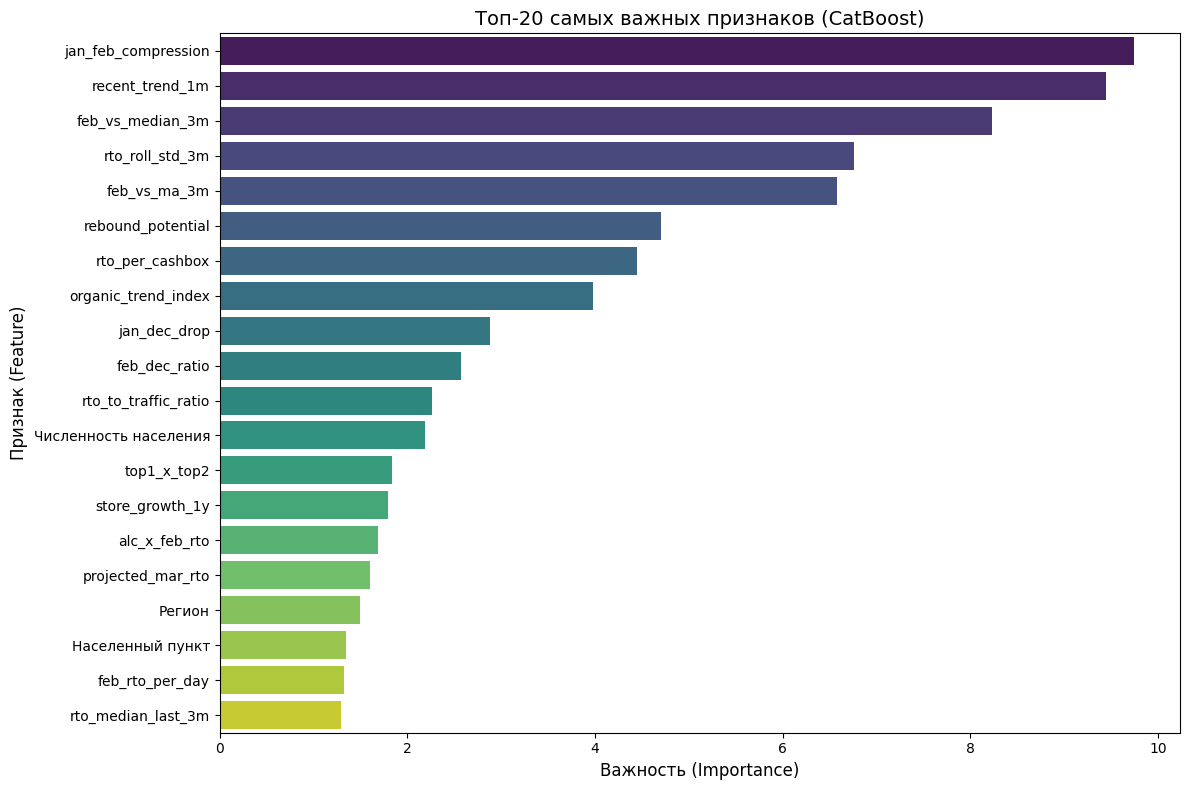

 ПОЛНЫЙ СПИСОК ПРИЗНАКОВ (Всего: 69)
                                      feature  importance
0                         jan_feb_compression    9.745645
1                             recent_trend_1m    9.448224
2                            feb_vs_median_3m    8.232068
3                             rto_roll_std_3m    6.759477
4                                feb_vs_ma_3m    6.582784
5                           rebound_potential    4.696793
6                             rto_per_cashbox    4.450815
7                         organic_trend_index    3.978444
8                                jan_dec_drop    2.885011
9                               feb_dec_ratio    2.572940
10                       rto_to_traffic_ratio    2.264660
11                      Численность населения    2.181726
12                                top1_x_top2    1.839223
13                            store_growth_1y    1.792967
14                              alc_x_feb_rto    1.687291
15                          project

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Формируем полный датафрейм важности
feature_importances = pd.DataFrame({
    'feature': model.feature_names_,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# 2. Строим расширенный график для Топ-20 (чтобы влезли новые фичи-лидеры)
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importances.head(20), x='importance', y='feature', palette='viridis')
plt.title('Топ-20 самых важных признаков (CatBoost)', fontsize=14)
plt.xlabel('Важность (Importance)', fontsize=12)
plt.ylabel('Признак (Feature)', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Выводим ВЕСЬ список без сокращений в консоль
print("="*60)
print(f" ПОЛНЫЙ СПИСОК ПРИЗНАКОВ (Всего: {len(feature_importances)})")
print("="*60)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.float_format', '{:.6f}'.format):
    print(feature_importances)

print("="*60)

In [34]:
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X_train_pure))
test_predictions = np.zeros(len(X_test_pure))
fold_scores = []

print("Начинаем 5-Fold кросс-валидацию CatBoost...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_pure)):
    X_tr = X_train_pure.iloc[train_idx].copy()
    X_val = X_train_pure.iloc[val_idx].copy()
    X_te = X_test_pure.copy()
    
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    train_orig = X_train.iloc[train_idx]
    regional_bump_map = train_orig.groupby('Регион')['hist_march_bump'].mean()
    regional_feb_mean_map = train_orig.groupby('Регион')['RTO_base_Feb'].mean()
    
    for df_fold in [X_tr, X_val, X_te]:
        df_fold['regional_march_bump'] = df_fold['Регион'].map(regional_bump_map).fillna(1.0).values
        
        if df_fold is X_tr:
            feb_rto = X_train.iloc[train_idx]['RTO_base_Feb']
        elif df_fold is X_val:
            feb_rto = X_train.iloc[val_idx]['RTO_base_Feb']
        else:
            feb_rto = X_test['RTO_base_Feb']
            
        reg_feb_mean = df_fold['Регион'].map(regional_feb_mean_map).fillna(1.0)
        # ИСПРАВЛЕНИЕ: Добавлен .values для защиты от дубликатов индексов
        df_fold['rto_vs_region_mean'] = feb_rto.values / reg_feb_mean.values
        df_fold['scaled_march_bump'] = (df_fold['hist_march_bump'] * df_fold['store_growth_1y']).values

    # ИСПРАВЛЕНИЕ: Добавлен .values для безопасного присвоения рангов
    X_tr['rto_feb_regional_rank'] = train_orig.groupby('Регион')['RTO_base_Feb'].rank(pct=True).values
    X_val['rto_feb_regional_rank'] = X_train.iloc[val_idx].groupby('Регион')['RTO_base_Feb'].rank(pct=True).values
    X_te['rto_feb_regional_rank'] = X_test.groupby('Регион')['RTO_base_Feb'].rank(pct=True).values
    # 3. Веса для обучения
    # Вес обратно пропорционален базовому значению. Чем меньше магазин, тем выше его важность для MAPE
    train_weights = 1.0 / (X_train.iloc[train_idx]['RTO_base_Feb'] + 1)
    # Нормализуем веса, чтобы они не были слишком крошечными
    train_weights = train_weights / train_weights.mean()

    # 4. Обучение модели
    model = CatBoostRegressor(
        iterations=5000,           
        learning_rate=0.018,       
        depth=6,                   
        l2_leaf_reg=7,             
        random_strength=2.0,
        colsample_bylevel=0.85,
        loss_function='RMSE',
        eval_metric='MAE',
        random_seed=42,   
        early_stopping_rounds=250,
        verbose=0                
    )
    
    model.fit(
        X_tr, y_tr,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        sample_weight=train_weights
    )
    
    # 5. Сбор предсказаний
    val_preds = model.predict(X_val)
    oof_predictions[val_idx] = val_preds
    
    fold_mae = model.best_score_['validation']['MAE']
    fold_scores.append(fold_mae)
    print(f"Fold {fold + 1} | MAE: {fold_mae:.5f}")
    
    test_predictions += model.predict(X_te) / 5

print(f"ИТОГОВЫЙ LOCAL MAE CATBOOST (OOF): {np.mean(fold_scores):.5f}")

Начинаем 5-Fold кросс-валидацию CatBoost...
Fold 1 | MAE: 0.03490
Fold 2 | MAE: 0.03496
Fold 3 | MAE: 0.03509
Fold 4 | MAE: 0.03472
Fold 5 | MAE: 0.03528
ИТОГОВЫЙ LOCAL MAE CATBOOST (OOF): 0.03499


In [35]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import re
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("Очищаем названия признаков от спецсимволов...")

def clean_names(name):
    return re.sub(r'[^A-Za-z0-9_А-Яа-яЁё]', '_', name).strip('_')

X_train_lgb = X_train_pure.copy()
X_test_lgb = X_test_pure.copy()

X_train_lgb.rename(columns=clean_names, inplace=True)
X_test_lgb.rename(columns=clean_names, inplace=True)

clean_cat_features = [clean_names(col) for col in cat_features]

for col in clean_cat_features:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

# Заранее определяем очищенные названия ключевых колонок для группировок
region_col = clean_names('Регион')
march_bump_col = clean_names('hist_march_bump')
feb_rto_col = clean_names('RTO_base_Feb')
growth_col = clean_names('store_growth_1y')

lgb_oof_predictions = np.zeros(len(X_train_lgb))
lgb_test_predictions = np.zeros(len(X_test_lgb))
lgb_fold_scores = []

print("\nНачинаем 5-Fold кросс-валидацию LightGBM...")

X_train_lgb = X_train_pure.copy()
X_test_lgb = X_test_pure.copy()
X_train_lgb.rename(columns=clean_names, inplace=True)
X_test_lgb.rename(columns=clean_names, inplace=True)

clean_cat_features = [clean_names(col) for col in cat_features]
for col in clean_cat_features:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

region_col = clean_names('Регион')
march_bump_col = clean_names('hist_march_bump')
growth_col = clean_names('store_growth_1y')

lgb_oof_predictions = np.zeros(len(X_train_lgb))
lgb_test_predictions = np.zeros(len(X_test_lgb))
lgb_fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_lgb)):
    X_tr = X_train_lgb.iloc[train_idx].copy()
    X_val = X_train_lgb.iloc[val_idx].copy()
    X_te = X_test_lgb.copy()
    
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    train_orig = X_train.iloc[train_idx]
    regional_bump_map = train_orig.groupby('Регион')['hist_march_bump'].mean()
    regional_feb_mean_map = train_orig.groupby('Регион')['RTO_base_Feb'].mean()
    
    for df_fold in [X_tr, X_val, X_te]:
        df_fold[clean_names('regional_march_bump')] = df_fold[region_col].astype(str).map(regional_bump_map).fillna(1.0).values
        
        if df_fold is X_tr:
            feb_rto = X_train.iloc[train_idx]['RTO_base_Feb']
        elif df_fold is X_val:
            feb_rto = X_train.iloc[val_idx]['RTO_base_Feb']
        else:
            feb_rto = X_test['RTO_base_Feb']
            
        reg_feb_mean = df_fold[region_col].astype(str).map(regional_feb_mean_map).fillna(1.0)
        # ИСПРАВЛЕНИЕ: Добавлен .values
        df_fold[clean_names('rto_vs_region_mean')] = feb_rto.values / reg_feb_mean.values
        df_fold[clean_names('scaled_march_bump')] = (df_fold[march_bump_col] * df_fold[growth_col]).values

    # ИСПРАВЛЕНИЕ: Добавлен .values
    X_tr[clean_names('rto_feb_regional_rank')] = train_orig.groupby('Регион')['RTO_base_Feb'].rank(pct=True).values
    X_val[clean_names('rto_feb_regional_rank')] = X_train.iloc[val_idx].groupby('Регион')['RTO_base_Feb'].rank(pct=True).values
    X_te[clean_names('rto_feb_regional_rank')] = X_test.groupby('Регион')['RTO_base_Feb'].rank(pct=True).values

    # 3. Веса для обучения
    # Вес обратно пропорционален базовому значению. Чем меньше магазин, тем выше его важность для MAPE
    train_weights = 1.0 / (X_train.iloc[train_idx]['RTO_base_Feb'].values + 1)
    train_weights = train_weights / train_weights.mean()

    # 4. Инициализация модели LightGBM
    model_lgb = lgb.LGBMRegressor(
        n_estimators=6000,
        learning_rate=0.012,
        boosting_type='gbdt',
        tree_learner='serial',
        extra_trees=True,            
        num_leaves=38,            # Исправлено: даем раскрыться асимметричным сплитам при depth=6
        max_depth=6,                 
        min_child_samples=35,     # Чуть-чуть увеличили для большей стабильности
        path_smooth=10.0,            
        subsample=0.75,              
        colsample_bytree=0.70,       
        reg_alpha=6.0,            # Чуть накинули L1, чтобы сильнее гасить шумовые гео-фичи
        reg_lambda=14.0,           # Чуть накинули L2 для сглаживания доминанта
        objective='mae',            
        metric='mae',
        random_state=42,
        n_jobs=-1,
        verbose=-1                 
    )
    
    callbacks = [lgb.early_stopping(stopping_rounds=250, verbose=False)]
    
    # 5. Обучение
    model_lgb.fit(
        X_tr, y_tr,
        sample_weight=train_weights,
        eval_set=[(X_val, y_val)],
        categorical_feature=clean_cat_features,
        callbacks=callbacks
    )
    
    val_preds = model_lgb.predict(X_val)
    lgb_oof_predictions[val_idx] = val_preds
    
    fold_mae = mean_absolute_error(y_val, val_preds)
    lgb_fold_scores.append(fold_mae)
    print(f"Fold {fold + 1} | Лучшая итерация: {model_lgb.best_iteration_} | MAE: {fold_mae:.5f}")
    
    lgb_test_predictions += model_lgb.predict(X_te) / 5

print(f"ИТОГОВЫЙ LIGHTGBM MAE (OOF): {np.mean(lgb_fold_scores):.5f}")

Очищаем названия признаков от спецсимволов...

Начинаем 5-Fold кросс-валидацию LightGBM...
Fold 1 | Лучшая итерация: 5952 | MAE: 0.03486
Fold 2 | Лучшая итерация: 3756 | MAE: 0.03525
Fold 3 | Лучшая итерация: 5991 | MAE: 0.03531
Fold 4 | Лучшая итерация: 5995 | MAE: 0.03555
Fold 5 | Лучшая итерация: 5691 | MAE: 0.03564
ИТОГОВЫЙ LIGHTGBM MAE (OOF): 0.03532


In [41]:
print("\nСмешиваем прогнозы CatBoost и LightGBM...")

blended_oof = (oof_predictions * 0.73) + (lgb_oof_predictions * 0.27)
blend_oof_mae = mean_absolute_error(y_train, blended_oof)
print(f"МАГИЯ АНСАМБЛЯ! OOF MAE Бленда: {blend_oof_mae:.5f}")


Смешиваем прогнозы CatBoost и LightGBM...
МАГИЯ АНСАМБЛЯ! OOF MAE Бленда: 0.03490


In [42]:
blended_test_coefs = (test_predictions * 0.73) + (lgb_test_predictions * 0.27)
# 2. Переводим коэффициенты в реальное РТО, умножая на Февраль 2025 года каждого магазина

final_blended_rto = blended_test_coefs * X_test['RTO_base_Feb']
# 3. Формируем итоговый датафрейм

submission_blend = pd.DataFrame({

    'new_id': X_test.index,

    'rto': final_blended_rto.values

})
submission_blend.to_csv('blend_catboost_lightgbm_full_data.csv', index=False)

посмотрим на локальную монополию магазов

Сигнал признака 'monopoly_index':
Линейная корреляция Пирсона: 0.08463
Ранговая корреляция Спирмена: 0.20455

Сравнение важности признаков (Mutual Information):
                     Признак  Mutual Information Score
              monopoly_index                  0.034382
Продуктовые магазины (500 м)                  0.033850
           Пятерочки (500 м)                  0.028213
         Трафик пеший, в час                  0.028046
             Количество касс                  0.007369


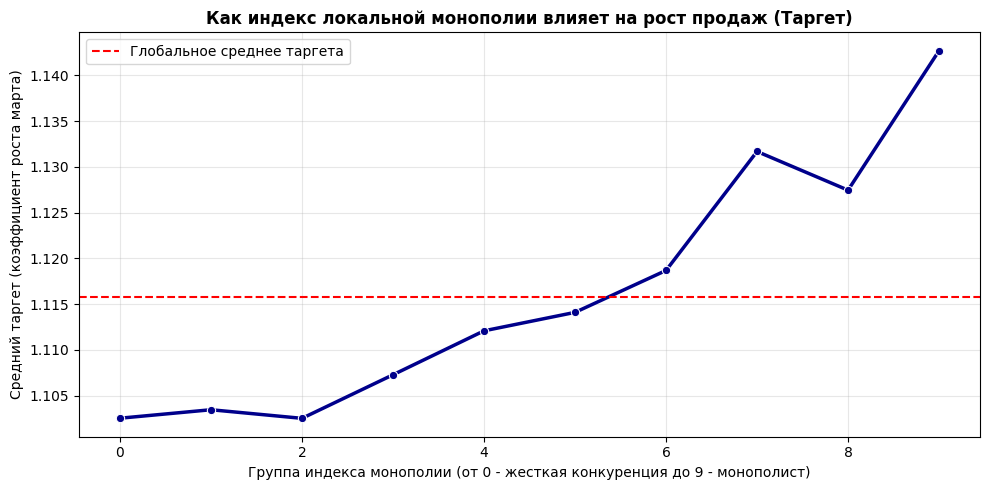

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

X_analysis = X_train.copy()
X_analysis['target_ratio'] = y_train

X_analysis['monopoly_index'] = X_analysis['Количество касс'] / (X_analysis['Продуктовые магазины (500 м)'] + 1)

pearson_corr = X_analysis['monopoly_index'].corr(X_analysis['target_ratio'], method='pearson')
spearman_corr = X_analysis['monopoly_index'].corr(X_analysis['target_ratio'], method='spearman')

print(f"Сигнал признака 'monopoly_index':")
print(f"Линейная корреляция Пирсона: {pearson_corr:.5f}")
print(f"Ранговая корреляция Спирмена: {spearman_corr:.5f}")


check_cols = [
    'Количество касс', 
    'Продуктовые магазины (500 м)', 
    'Пятерочки (500 м)', 
    'Трафик пеший, в час',
    'monopoly_index'
]

df_mi = X_analysis[check_cols].fillna(0)
mi_scores = mutual_info_regression(df_mi, X_analysis['target_ratio'], random_state=42)

mi_results = pd.DataFrame({
    'Признак': check_cols,
    'Mutual Information Score': mi_scores
}).sort_values('Mutual Information Score', ascending=False)

print("\nСравнение важности признаков (Mutual Information):")
print(mi_results.to_string(index=False))

X_analysis['monopoly_bin'] = pd.qcut(X_analysis['monopoly_index'], q=10, labels=False, duplicates='drop')
binned_data = X_analysis.groupby('monopoly_bin')['target_ratio'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=binned_data, x='monopoly_bin', y='target_ratio', marker='o', color='darkblue', linewidth=2.5)
plt.axhline(X_analysis['target_ratio'].mean(), color='red', linestyle='--', label='Глобальное среднее таргета')
plt.title('Как индекс локальной монополии влияет на рост продаж (Таргет)', fontsize=12, fontweight='bold')
plt.xlabel('Группа индекса монополии (от 0 - жесткая конкуренция до 9 - монополист)')
plt.ylabel('Средний таргет (коэффициент роста марта)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
final_rto_predictions = test_predictions * X_test['RTO_base_Feb']

submission = pd.DataFrame({
    'new_id': X_test.index,
    'rto': final_rto_predictions.values
})
submission['rto'] = submission['rto'].clip(lower=X_test['RTO_base_Feb'].min())
submission.to_csv('catboost_cv5_mom_new_features.csv', index=False)

In [28]:
import pandas as pd

# 1. Загружаем лучший сабмит коллеги
colleague_sub = pd.read_csv('/kaggle/input/datasets/viacheslavkrutoyatov/submissions/_submission888.csv')

# Гарантируем, что порядок магазинов у коллеги строго совпадает с вашим X_test
colleague_sub = colleague_sub.set_index('new_id').loc[X_test.index]

# 2. Считаем ваш внутренний бленд коэффициентов (как и раньше)
my_blended_coefs = (test_predictions * 0.73) + (lgb_test_predictions * 0.27)

# 3. Переводим ваш прогноз в абсолютный РТО (в рубли)
my_final_rto = my_blended_coefs * X_test['RTO_base_Feb']

# 4. Делаем финальное "золотое сечение" между вашими рублями и рублями коллеги
# Даем вашему (более сильному) решению вес 70%, а его — 30%
final_super_rto = (my_final_rto * 0.7) + (colleague_sub['rto'] * 0.3)

# 5. Формируем итоговый датафрейм для отправки
submission_final = pd.DataFrame({
    'new_id': X_test.index,
    'rto': final_super_rto.values
})

# Защита от отрицательных значений (клипаем по нулю, чтобы не перестраховываться слишком сильно)
submission_final['rto'] = submission_final['rto'].clip(lower=0)

# Сохраняем финальный файл
submission_final.to_csv('super_blend_90_plus.csv', index=False)
print("Файл успешно создан! Время отправлять на ЛБ.")

Файл успешно создан! Время отправлять на ЛБ.
